In [19]:
import pandas as pd

df = pd.read_csv("test.csv")
df.drop_duplicates(subset=['model_path'], keep='last', inplace=True)



best = df.groupby("model_path")["accuracy"].max().reset_index()
top5 = best.sort_values("accuracy", ascending=False).head(10)

print("Топ-5 моделей по accuracy:")
for _, row in top5.iterrows():
    print(f"{row['model_path']}: accuracy = {row['accuracy']:.4f}")

Топ-5 моделей по accuracy:
best_model_optuna.pt: accuracy = 0.9270
/kaggle/working/baseline_d384_h12_l4_ff1536_do02_wd10_best.pt: accuracy = 0.9262
/kaggle/working/baseline_d384_h12_l4_ff1536_do02_wd05_best.pt: accuracy = 0.9242
/kaggle/working/baseline_d384_h12_l4_ff1536_do02_wd10_lr2e04_best.pt: accuracy = 0.9209
/kaggle/working/baseline_d384_h12_l4_ff1536_do02_wd01_best.pt: accuracy = 0.9200
/kaggle/working/baseline_d384_h12_l4_ff1536_do02_wd001_best.pt: accuracy = 0.9197
/kaggle/working/baseline_d384_h12_l4_ff1536_do02_wd20_best.pt: accuracy = 0.9189
/kaggle/working/baseline_d384_h12_l5_ff1536_do02_wd001_best.pt: accuracy = 0.9187
/kaggle/working/baseline_d384_h12_l4_ff1536_do02_wd30_best.pt: accuracy = 0.9182
/kaggle/working/baseline_d256_h4_l4_ff1024_do02_wd001_best.pt: accuracy = 0.9174


TOP-5 MODELS WITH PARAMETERS
                                                          model_path  accuracy  f1_macro  d_model  num_heads  ff_hidden_dim  num_layers  dropout  weight_decay
                                                best_model_optuna.pt  0.926974  0.926770      192          6            768           5      0.3      0.012477
       /kaggle/working/baseline_d384_h12_l4_ff1536_do02_wd10_best.pt  0.926184  0.926077      384         12           1536           4      0.2      1.000000
       /kaggle/working/baseline_d384_h12_l4_ff1536_do02_wd05_best.pt  0.924211  0.923956      384         12           1536           4      0.2      0.500000
/kaggle/working/baseline_d384_h12_l4_ff1536_do02_wd10_lr2e04_best.pt  0.920921  0.920814      384         12           1536           4      0.2      1.000000
       /kaggle/working/baseline_d384_h12_l4_ff1536_do02_wd01_best.pt  0.920000  0.919633      384         12           1536           4      0.2      0.100000


BEST MODEL
Mode

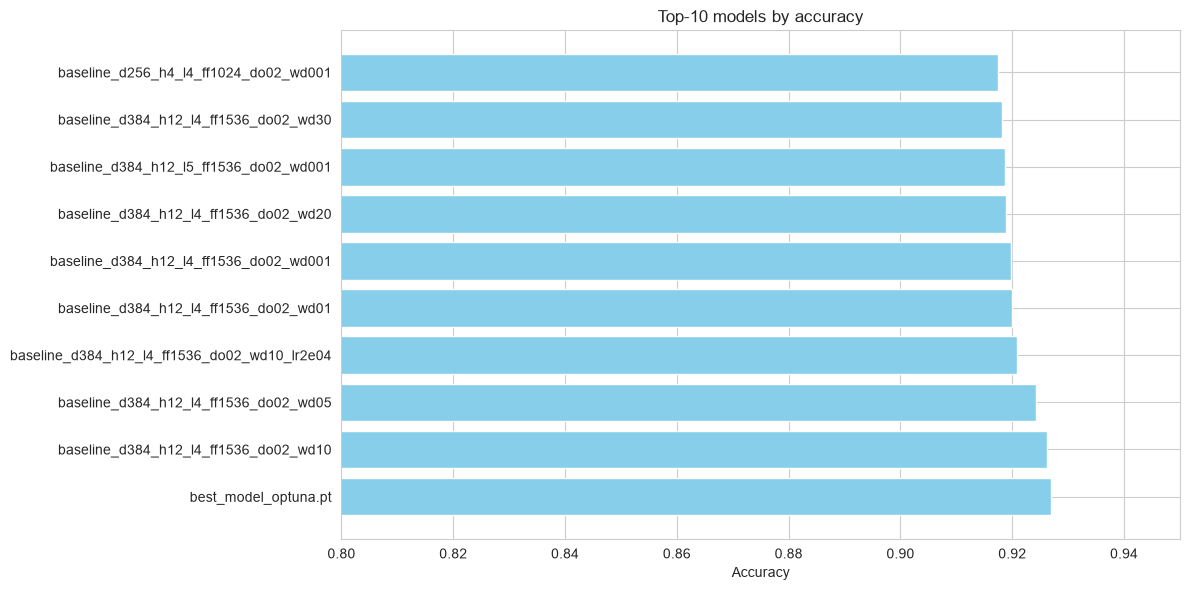

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("test.csv")

sns.set_style("whitegrid")

top5 = top10.head(5)
print("TOP-5 MODELS WITH PARAMETERS")
print(top5.to_string(index=False))
print("\n")

# Best model
best = df.loc[df["accuracy"].idxmax()]
print("BEST MODEL")
print(f"Model: {best['model_path']}")
print(f"Accuracy: {best['accuracy']:.4f}")
print(f"F1-macro: {best['f1_macro']:.4f}")
print(f"Parameters: d_model={best['d_model']}, num_heads={best['num_heads']}, ff_hidden_dim={best['ff_hidden_dim']}, num_layers={best['num_layers']}, dropout={best['dropout']}, weight_decay={best['weight_decay']}")
print("\n")

# Hyperparameter influence (average accuracy)
print("HYPERPARAMETER INFLUENCE (average accuracy)")
for param in ["d_model", "num_heads", "num_layers", "dropout", "weight_decay"]:
    if param in df.columns:
        grouped = df.groupby(param)["accuracy"].mean().sort_values(ascending=False)
        print(f"\n{param}:")
        print(grouped.head(5).to_string())
print("\n")

# Plots with y-axis 0.80-0.95
plt.figure(figsize=(12, 6))
top10_plot = df.nlargest(10, "accuracy").sort_values("accuracy", ascending=False)
plt.barh(top10_plot["model_path"].str.replace("_best.pt", "").str.replace("/kaggle/working/", ""), 
         top10_plot["accuracy"], color="skyblue")
plt.xlabel("Accuracy")
plt.title("Top-10 models by accuracy")
plt.xlim(0.80, 0.95)
plt.tight_layout()
plt.savefig("top10_accuracy.png", dpi=150)
plt.show()
